In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET
from mis_dro.models import univariate_GaussianModel
from mis_dro.npl import Npl
from mis_dro.dataset import *
from mis_dro.npl import *
from mis_dro.likelihood import *
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.gaussian_kernel import *
from mis_dro.bayes_conjugates import *

/tmp/dcs-tmp.u1604520/ipykernel_366263/2474241309.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
contamination = 0.2
num_observations = 100
num_posterior_samples = 100
num_likelihood_samples = 100
likelihood = "normal"
contam_data = sample_dgp("contaminated_normal", num_observations, contamination)
non_contam_data = sample_dgp("normal", num_observations)

In [3]:
generator = np.random.default_rng(seed=0)
theta_sample_mmd_cont = sample_npl(
    contam_data,
    "npl_mmd",
    likelihood,
    num_posterior_samples,
    seed=0,
    lengthscale=-1,
    generator=generator,
)
theta_sample_mmd_noncont = sample_npl(
    non_contam_data,
    "npl_mmd",
    likelihood,
    num_posterior_samples,
    seed=0,
    lengthscale=-1,
    generator=generator,
)


In [4]:
def approx_mmd(sample1, sample2):
    m = len(sample1)
    n = len(sample2)
    
    sample1 = sample1.reshape((m,1))
    sample2 = sample2.reshape((n,1))
    
    l = np.sqrt((1/2)*np.median(distance.cdist(sample2, sample2, 'sqeuclidean')))
    
    kyy = k_jax(sample1, sample1, l)
    kxy = k_jax(sample1, sample2, l)
    kxx = k_jax(sample2, sample2, l)

   # first sum
    diag_elements = jnp.diag_indices_from(kyy)
    kyy = kyy.at[diag_elements].set(jnp.repeat(0, m))
    sum1 = jnp.sum(kyy)

    # second sum
    sum2 = jnp.sum(kxy)

    # third sum
    diag_elements = jnp.diag_indices_from(kxx)
    kxx = kxx.at[diag_elements].set(jnp.repeat(0, n))
    sum3 = jnp.sum(kxx)

    return (
        np.sqrt((1 / (m * (m - 1))) * sum1
        - (2 / (n * m)) * sum2
        + (1 / (n * (n - 1))) * sum3)
    )

In [5]:
def approx_kl(mu1, std1, mu2, std2):
    return(np.log(std2/std1) +
           std1**2/(2*std2**2) +
           (mu1 - mu2)**2/(2*std2**2) -
           0.5)

In [6]:
from scipy.spatial import ConvexHull, convex_hull_plot_2d

posterior = "normal_gamma"
likelihood = "normal"
dim = 1
theta_prior = default_prior_params(posterior)
theta_posterior = get_posterior_params(posterior, non_contam_data, theta_prior)
theta_sample_kl = sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator)
theta_pp = posterior_predictive_params(posterior, theta_posterior)
pp_sample_kl = sample_posterior_predictive(likelihood, posterior, theta_pp, dim, num_likelihood_samples, generator)
mean_range = np.linspace(0, 50, num=40)
std_range = np.linspace(0.001, 50, num=40)

def compute_bas(epsilon):
    pairs_inside_BASPE = []
    for mu, std in itertools.product(mean_range, std_range):
        kls = np.zeros(num_posterior_samples)
        for j in range(num_posterior_samples):
            kls[j] = approx_kl(mu, std, theta_sample_kl[j,0], theta_sample_kl[j,1])    
        exp_kl = kls.mean()
        if exp_kl < epsilon:
            pairs_inside_BASPE.append((mu,std))
    if not pairs_inside_BASPE or len(pairs_inside_BASPE) < 3:
        return 0.0
    else:
        hull = ConvexHull(np.array(pairs_inside_BASPE))
        return hull.volume

def compute_baspp(epsilon):
    pairs_inside_BASPP = []
    mu_pp, scale_pp, dof = theta_pp
    q = sp.stats.t(df=dof, loc=mu_pp, scale=scale_pp)
    for mu, std in itertools.product(mean_range, std_range):
        # kls = np.zeros(num_posterior_samples)
        # for j in range(num_posterior_samples*num_likelihood_samples):
        #     pp_sample[j] = approx_kl(mu, std, theta_sample_kl[j,0], theta_sample_kl[j,1])    
        # exp_kl = kls.mean()
        p_samples = generator.normal(
            loc=mu,
            scale=std,
            size=num_likelihood_samples*num_posterior_samples,
        ) 
        p = sp.stats.norm(loc=mu, scale=std)
        kl = np.mean(np.log(p.pdf(p_samples) / q.pdf(p_samples)))
        if kl < epsilon:
            pairs_inside_BASPP.append((mu,std))
    if not pairs_inside_BASPP or len(pairs_inside_BASPP) < 3:
        return 0.0
    else:
        hull = ConvexHull(np.array(pairs_inside_BASPP))
        return hull.volume
    
def compute_robas(epsilon):
    pairs_inside_RoBAS = []
    for mu, std in itertools.product(mean_range, std_range):
        # sample from P
        samples_from_P = generator.normal(
            loc=mu,
            scale=std,
            size=num_likelihood_samples,
        ) 
        
        # for each theta calculate approximate MMD
        mmds = np.zeros(num_posterior_samples)
        samples_from_Ptheta = np.zeros((num_posterior_samples, num_likelihood_samples))
        for j in range(num_posterior_samples):
            samples_from_Ptheta[j,:] = generator.normal(
                loc=theta_sample_mmd[j,0],
                scale=theta_sample_mmd[j,1],
                size=num_likelihood_samples,
            )
        mean_samples = samples_from_Ptheta.mean(axis=0)
            # mmds[j] = approx_mmd(samples_from_P, samples_from_Ptheta)
        # exp_mmd = mmds.mean()
        exp_mmd = approx_mmd(samples_from_P, mean_samples)
        if exp_mmd < epsilon:
            pairs_inside_RoBAS.append((mu,std))
    
    if not pairs_inside_RoBAS or len(pairs_inside_RoBAS) < 3:
        return 0.0
    else:
        hull = ConvexHull(np.array(pairs_inside_RoBAS))
        return hull.volume
    
    



In [7]:
# # Find epsilon_1 and epsilon_2 
# from mis_dro.constants import BAS_DRO_EPSILON_SET

# areas_bas = []
# areas_robas = []
# for epsilon in BAS_DRO_EPSILON_SET:
#     print(epsilon)
#     bas = compute_bas(epsilon)
#     robas = compute_robas(epsilon)
#     areas_bas.append(bas)
#     areas_robas.append(robas)
    
    

In [8]:
# print(areas_bas, BAS_DRO_EPSILON_SET, "areas_bas")
# print(areas_robas, BAS_DRO_EPSILON_SET, "areas_robas")

In [9]:
pip install tqdm

/dcs/pg23/u1604520/.conda/envs/mis-dro/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [11]:
# Now I want to visualise the DRO-RoBAS for these samples 
# Ideally I would be able to sample densities P and then see if E[MMD(P, P_theta)] < epsilon 
# I can do this by using my theta samples and approximmating E[MMD()] = 1/B \sum_{b=1}^N MMD(P, P_{theta_b})
# Main question is how to sample P?
# A toy example would be to sample just different means for the Gaussian likelihood
from tqdm import tqdm
mean_range = np.linspace(0, 50, num=50)
std_range = np.linspace(0.001, 50, num=50)
cmap = plt.get_cmap('RdYlBu')
for i, data in enumerate([non_contam_data, contam_data]):
    pairs_inside_RoBAS = []
    pairs_inside_BASPE = []
    pairs_inside_BASPP = []
    if i == 1:
        dataset_name = "contaminated data"
        theta_sample_mmd = theta_sample_mmd_cont
    else:
        dataset_name = "non-contaminated data"
        theta_sample_mmd = theta_sample_mmd_noncont
    
    posterior = "normal_gamma"
    likelihood = "normal"
    dim = 1 
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    theta_sample_kl = sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator)
    theta_pp = posterior_predictive_params(posterior, theta_posterior)
    pp_sample_kl = sample_posterior_predictive(likelihood, posterior, theta_pp, dim, num_likelihood_samples, generator)
    mu_pp, scale_pp, dof = theta_pp[0]
    q = sp.stats.t(df=dof, loc=mu_pp, scale=scale_pp)

    for mu, std in tqdm(itertools.product(mean_range, std_range)):
        # sample from P
        samples_from_P = generator.normal(
            loc=mu,
            scale=std,
            size=num_likelihood_samples,
        ) 
        
        # for each theta calculate approximate MMD
        epsilon = 0.35
        mmds = np.zeros(num_posterior_samples)
        for j in range(num_posterior_samples):
            samples_from_Ptheta = generator.normal(
                loc=theta_sample_mmd[j,0],
                scale=theta_sample_mmd[j,1],
                size=num_likelihood_samples,
            )
            
            mmds[j] = approx_mmd(samples_from_P, samples_from_Ptheta)
        exp_mmd = mmds.mean()
        if exp_mmd < epsilon:
            pairs_inside_RoBAS.append((mu,std))
            
        # for each theta calculate approximate KL
        epsilon = 0.35
        kls = np.zeros(num_posterior_samples)
        for j in range(num_posterior_samples):
            kls[j] = approx_kl(mu, std, theta_sample_kl[j,0], theta_sample_kl[j,1])
            
        exp_kl = kls.mean()
        if exp_kl < epsilon:
            pairs_inside_BASPE.append((mu,std))

        # PP
        p = sp.stats.norm(loc=mu, scale=std)
        kl = np.mean(np.log(p.pdf(samples_from_P) / q.pdf(samples_from_P)))
        if kl < epsilon:
            pairs_inside_BASPP.append((mu,std))

    if i == 0:
        non_contam_pairs_BASPE = np.array(pairs_inside_BASPE)
        non_contam_pairs_BASPP = np.array(pairs_inside_BASPP)
        non_contam_pairs_RoBAS = np.array(pairs_inside_RoBAS)

    else:
        contam_pairs_BASPE = np.array(pairs_inside_BASPE)
        contam_pairs_BASPP = np.array(pairs_inside_BASPP)
        contam_pairs_RoBAS = np.array(pairs_inside_RoBAS)
    # print(pairs_RoBAS)


    

808it [13:01,  1.04it/s]/tmp/dcs-tmp.u1604520/ipykernel_344286/663165673.py:28: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt((1 / (m * (m - 1))) * sum1
2178it [34:44,  1.06it/s]

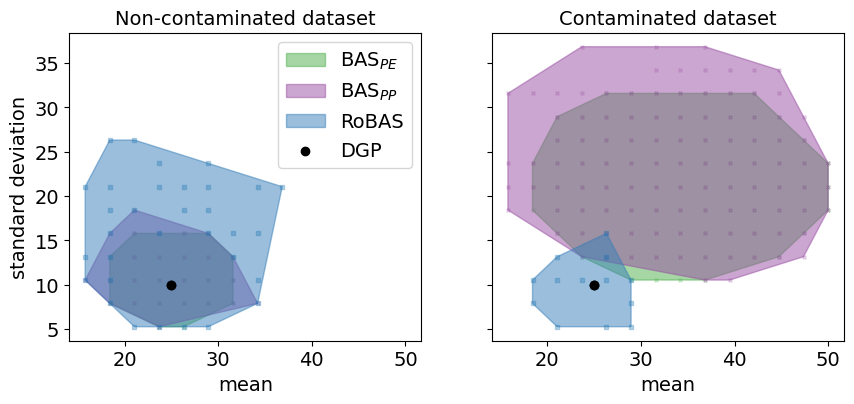

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharex=True, sharey=True)

ax = axes[0]
pairs_BASPE = non_contam_pairs_BASPE
pairs_BASPP = non_contam_pairs_BASPP
pairs_RoBAS = non_contam_pairs_RoBAS

hull = sp.spatial.ConvexHull(pairs_BASPE)
xy = np.array([pairs_BASPE[hull.vertices, 0], pairs_BASPE[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#4daf4a")
patch = ax.add_patch(polygon)
ax.scatter(pairs_BASPE[:,0], pairs_BASPE[:, 1], alpha=0.3, marker="x", color="#4daf4a", s=6)
ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title(f'BAS with {dataset_name} dataset')
ax.set_ylabel('standard deviation')

hull = sp.spatial.ConvexHull(pairs_BASPP)
xy = np.array([pairs_BASPP[hull.vertices, 0], pairs_BASPP[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#984ea3")
pp_patch = ax.add_patch(polygon)
ax.scatter(pairs_BASPP[:,0], pairs_BASPP[:, 1], alpha=0.3, marker="x", color="#984ea3", s=6)
ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title(f'BAS with {dataset_name} dataset')
# ax.set_ylabel('standard deviation')

hull = sp.spatial.ConvexHull(pairs_RoBAS)
xy = np.array([pairs_RoBAS[hull.vertices, 0], pairs_RoBAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#377eb8")
ro_patch = ax.add_patch(polygon)
ax.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:, 1], alpha=0.3, marker="s", s=6)
dgp = ax.scatter(25, 10, color="black", alpha=1, marker="o")
ax.set_title('Non-contaminated dataset', size=14)
ax.set_xlabel('mean', size=14)
ax.set_ylabel('standard deviation', size=14)
ax.legend([patch, pp_patch, ro_patch, dgp], ["BAS$_{PE}$", "BAS$_{PP}$", "RoBAS", "DGP"], loc='upper right', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

ax = axes[1]
pairs_BASPE = contam_pairs_BASPE
pairs_BASPP = contam_pairs_BASPP
pairs_RoBAS = contam_pairs_RoBAS

hull = sp.spatial.ConvexHull(pairs_BASPE)
xy = np.array([pairs_BASPE[hull.vertices, 0], pairs_BASPE[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#4daf4a")
patch = ax.add_patch(polygon)
ax.scatter(pairs_BASPE[:,0], pairs_BASPE[:, 1], alpha=0.3, marker="x", color="#4daf4a", s=6)
ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title(f'BAS with {dataset_name} dataset')
# ax.set_ylabel('standard deviation', size=12)

hull = sp.spatial.ConvexHull(pairs_BASPP)
xy = np.array([pairs_BASPP[hull.vertices, 0], pairs_BASPP[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#984ea3")
patch = ax.add_patch(polygon)
ax.scatter(pairs_BASPP[:,0], pairs_BASPP[:, 1], alpha=0.3, marker="x", color="#984ea3", s=6)
ax.scatter(25, 10, color="black", alpha=1, marker="o")

hull = sp.spatial.ConvexHull(pairs_RoBAS)
xy = np.array([pairs_RoBAS[hull.vertices, 0], pairs_RoBAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="#377eb8")
ro_patch = ax.add_patch(polygon)
ax.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:, 1], alpha=0.3, marker="s", s=6)
dgp = ax.scatter(25, 10, color="black", alpha=1, marker="o")
ax.set_title('Contaminated dataset', size=14)
ax.set_xlabel('mean', size=14)
ax.tick_params(axis='both', labelsize=14)
# ax.set_ylabel('standard deviation')
# ax.legend([patch, ro_patch, dgp], ["BAS", "RoBAS", "DGP"], loc='upper left')

# plt.tight_layout()

IndexError: tuple index out of range

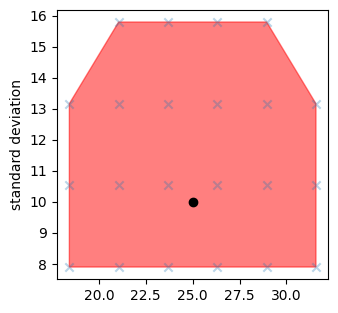

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,3.5), sharex=True, sharey=True)

pairs_BAS = non_contam_pairs_BAS
pairs_RoBAS = non_contam_pairs_RoBAS

hull = sp.spatial.ConvexHull(pairs_BAS)
xy = np.array([pairs_BAS[hull.vertices, 0], pairs_BAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="red")
patch = ax.add_patch(polygon)
ax.scatter(pairs_BAS[:,0], pairs_BAS[:, 1], alpha=0.3, marker="x")
ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title(f'BAS with {dataset_name} dataset')
ax.set_ylabel('standard deviation')

hull = sp.spatial.ConvexHull(pairs_RoBAS)
xy = np.array([pairs_RoBAS[hull.vertices, 0], pairs_RoBAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="green")
ro_patch = ax.add_patch(polygon)
ax.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:, 1], alpha=0.3, marker="s")
dgp = ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title('Non-contaminated dataset')
ax.set_xlabel('mean')
ax.set_ylabel('standard deviation')
ax.legend([patch, ro_patch, dgp], ["BAS", "RoBAS", "DGP"], loc='upper left')

plt.tight_layout()

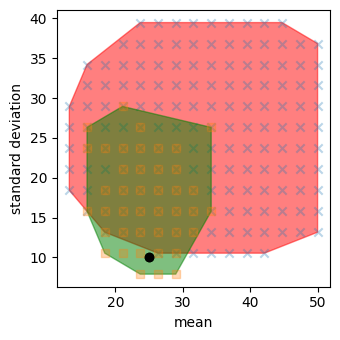

In [66]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,3.5), sharex=True, sharey=True)

pairs_BAS = contam_pairs_BAS
pairs_RoBAS = contam_pairs_RoBAS

hull = sp.spatial.ConvexHull(pairs_BAS)
xy = np.array([pairs_BAS[hull.vertices, 0], pairs_BAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="red")
patch = ax.add_patch(polygon)
ax.scatter(pairs_BAS[:,0], pairs_BAS[:, 1], alpha=0.3, marker="x")
ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title(f'BAS with {dataset_name} dataset')
ax.set_ylabel('standard deviation')

hull = sp.spatial.ConvexHull(pairs_RoBAS)
xy = np.array([pairs_RoBAS[hull.vertices, 0], pairs_RoBAS[hull.vertices, 1]]).T
polygon = mpl.patches.Polygon(xy, alpha=0.5, color="green")
ro_patch = ax.add_patch(polygon)
ax.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:, 1], alpha=0.3, marker="s")
dgp = ax.scatter(25, 10, color="black", alpha=1, marker="o")
# ax.set_title('Contaminated dataset')
ax.set_xlabel('mean')
ax.set_ylabel('standard deviation')
# ax.legend([patch, ro_patch, dgp], ["BAS", "RoBAS", "DGP"], loc='upper left')

plt.tight_layout()

(198, 2)


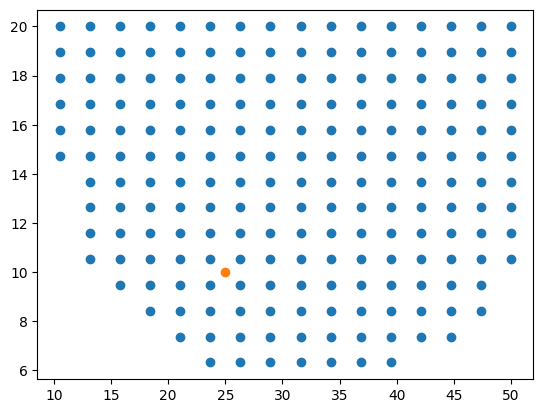

In [8]:
pairs_BAS = np.array(pairs_inside_BAS)
pairs_RoBAS = np.array(pairs_inside_RoBAS)
print(pairs_BAS.shape)
plt.scatter(pairs_BAS[:,0], pairs_BAS[:,1])
plt.scatter(25, 10)
# plt.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:,1])

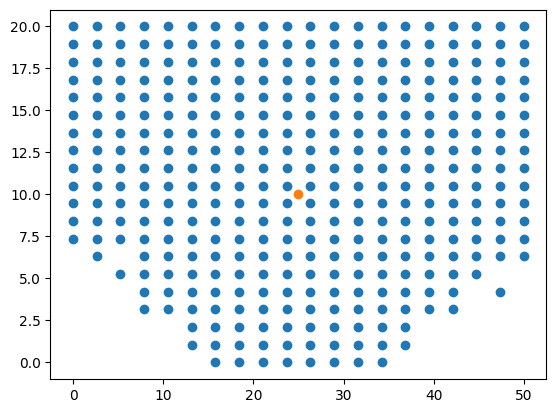

In [78]:
plt.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:,1])
plt.scatter(25, 10)

In [9]:
def get_regular_grid(z_samples: np.array, epsilon: float) -> np.array:
    """Get a grid that easily covers the epsilon ball"""
    n_points = 200
    margin = 0.2
    z_mean = np.mean(z_samples, axis=0)
    x_axis = np.linspace(
        start=min(np.min(z_samples[:, 0]), z_mean[0] - epsilon - margin), 
        stop=max(np.max(z_samples[:, 0]), z_mean[0] + epsilon + margin),
        num=n_points,
    )
    y_axis = np.linspace(
        start=min(np.min(z_samples[:, 1]), z_mean[1] - epsilon - margin),
        stop=max(np.max(z_samples[:, 1]), z_mean[1] + epsilon + margin),
        num=n_points
    )
    xv, yv = np.array(np.meshgrid(x_axis, y_axis))
    return np.array([xv.flatten(), yv.flatten()]).T

# Try to replicate example from Gao

In [3]:
def contaminated_normal(num_observations: int, contamination: float, random_state: Optional[np.random.Generator] = None):
    """A contaminated Gaussian data-generating process (DGP)

    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided

    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data = norm.rvs(loc=25, scale=DGP_STD_TRUNCATED_NORMAL, size=n_real, random_state=random_state) 
    outl = norm.rvs(loc=75, scale=DGP_STD_TRUNCATED_NORMAL, size=cont_size, random_state=random_state) #75
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffles the data in-place
    return data, outl

In [15]:
contaminations = [0.0, 0.2]
num_observations = 200
num_posterior_samples = 200
num_likelihood_samples = 200
likelihood = "normal_known_var"
generator = np.random.default_rng(seed=0)
data_true = sample_dgp("contaminated_normal", 1000, contaminations[0])
data_observed, outl = contaminated_normal(num_observations, contaminations[1])
data_pathological = norm.rvs(
            loc=40,
            scale=DGP_STD_TRUNCATED_NORMAL,
            size=num_observations,
            random_state=generator,
        )
datasets = [data_true, data_observed, data_pathological]

In [16]:
generator = np.random.default_rng(seed=0)
theta_sample_mmd = sample_npl(
data_observed,
"npl_mmd",
likelihood,
num_posterior_samples,
seed=0,
lengthscale=-1,
generator=generator,
)
posterior = "normal"
# theta_prior = default_prior_params(posterior)
mu_prior, sigma_prior = 0.0, 10.0
data_mean = np.mean(data_observed)
true_var = DGP_STD_TRUNCATED_NORMAL**2
mu_posterior = (true_var * mu_prior + num_observations * sigma_prior**2 * data_mean) / (
    num_observations * sigma_prior**2 + true_var
)
sigma_posterior = np.sqrt(sigma_prior**2*true_var/(true_var+num_observations*sigma_prior**2))
# theta_posterior = get_posterior_params(posterior, data_observed, theta_prior)
# theta_sample_kl = sample_posterior(posterior, theta_posterior, num_posterior_samples, generator=generator) 
theta_sample_kl = norm.rvs(
        loc=mu_posterior,
        scale=sigma_posterior,
        size=num_posterior_samples,
        random_state=generator,
        )


theta_sample_pp = norm.rvs(
        loc=mu_posterior,
        scale=np.sqrt(sigma_posterior**2+true_var),
        size=num_posterior_samples,
        random_state=generator,
        )

In [17]:
def kl_approx_pp(
    p: sp.stats.rv_continuous,
    q: sp.stats.rv_continuous,
    p_samples,
) -> float:
    """KL divergence approximation using Monte Carlo
    Args:
        p: scipy continuous distribution
        q: scipy continuous distribution
        num_samples: number of samples to approximation expectation over p
        generator: numpy random number generator
    Returns:
        KL divergence between p and q
    Notes:
        The KL is the integral of p(x) log(p(x)/q(x)).
        This can be written as the expected value under p(x) of the log term.
        We sample from p(x) then evaluate the expectation of the log term under these samples.
    """
    # draw samples from p
    # then calculate the expectation using the samples
    return np.mean(np.log(p.pdf(p_samples) / q.pdf(p_samples)))

In [18]:
def approx_mmd(sample1, sample2):
    m = len(sample1)
    n = len(sample2)
    
    sample1 = sample1.reshape((m,1))
    sample2 = sample2.reshape((n,1))
    
    l = np.sqrt((1/2)*np.median(distance.cdist(sample2, sample2, 'sqeuclidean')))
    
    kyy = k_jax(sample1, sample1, l)
    kxy = k_jax(sample1, sample2, l)
    kxx = k_jax(sample2, sample2, l)

   # first sum
    diag_elements = jnp.diag_indices_from(kyy)
    kyy = kyy.at[diag_elements].set(jnp.repeat(0, m))
    sum1 = jnp.sum(kyy)

    # second sum
    sum2 = jnp.sum(kxy)

    # third sum
    diag_elements = jnp.diag_indices_from(kxx)
    kxx = kxx.at[diag_elements].set(jnp.repeat(0, n))
    sum3 = jnp.sum(kxx)

    return (
        np.sqrt((1 / (m * (m - 1))) * sum1
        - (2 / (n * m)) * sum2
        + (1 / (n * (n - 1))) * sum3)
    )

In [19]:
# Compute expected KL and expected MMD distance from pathological case and MMD


samples_from_P = generator.normal(
        loc=40,
        scale=DGP_STD_TRUNCATED_NORMAL,
        size=1000,
    )
 
# MMD
# for each theta calculate approximate MMD 
# to P
mmds_P = np.zeros(num_posterior_samples)
mmds_DGP = np.zeros(num_posterior_samples)
samples_from_Ptheta = np.zeros((num_posterior_samples, num_likelihood_samples))
for i in range(num_posterior_samples):
    samples_from_Ptheta[i,:] = generator.normal(
        loc=theta_sample_mmd[i],
        scale=DGP_STD_TRUNCATED_NORMAL,
        size=num_likelihood_samples,
    )
    
    # mmds_P[i] = approx_mmd(samples_from_P, samples_from_Ptheta)
    # mmds_DGP[i] = approx_mmd(data_true, samples_from_Ptheta)
mean_samples_from_Ptheta = samples_from_Ptheta.mean(axis=0)
exp_mmd_P = approx_mmd(samples_from_P, mean_samples_from_Ptheta) #mmds_P.mean()
exp_mmd_DGP = approx_mmd(data_true, mean_samples_from_Ptheta)#mmds_DGP.mean()
    

# KL
# for each theta calculate approximate KL
# to P
kls_P = np.zeros(num_posterior_samples)
kls_DGP = np.zeros(num_posterior_samples)
for i in range(num_posterior_samples):  
    kls_P[i] = approx_kl(40, DGP_STD_TRUNCATED_NORMAL, theta_sample_kl[i], DGP_STD_TRUNCATED_NORMAL)
    kls_DGP[i] = approx_kl(25, DGP_STD_TRUNCATED_NORMAL, theta_sample_kl[i],  DGP_STD_TRUNCATED_NORMAL)
exp_kl_P = kls_P.mean()
exp_kl_DGP = kls_DGP.mean()

# KL PP
kls_PP = np.zeros(num_posterior_samples)
kls_DGPP = np.zeros(num_posterior_samples)
mean_theta_sample_pp = theta_sample_pp.mean()
# for i in range(num_posterior_samples):  
#     kls_PP[i] = approx_kl(40, DGP_STD_TRUNCATED_NORMAL, theta_sample_pp[i], DGP_STD_TRUNCATED_NORMAL)
#     kls_DGPP[i] = approx_kl(25, DGP_STD_TRUNCATED_NORMAL, theta_sample_pp[i],  DGP_STD_TRUNCATED_NORMAL)
exp_kl_PP = kl_approx_pp(sp.stats.norm(loc=40, scale=DGP_STD_TRUNCATED_NORMAL), sp.stats.norm(loc=mean_theta_sample_pp, scale=DGP_STD_TRUNCATED_NORMAL), samples_from_P) #kls_PP.mean()
exp_kl_DGPP = kl_approx_pp(sp.stats.norm(loc=25, scale=DGP_STD_TRUNCATED_NORMAL), sp.stats.norm(loc=mean_theta_sample_pp, scale=DGP_STD_TRUNCATED_NORMAL), data_true) #kls_DGPP.mean()

print(exp_mmd_P, exp_mmd_DGP, "MMD")
print(exp_kl_P, exp_kl_DGP, "KL")
print(exp_kl_PP, exp_kl_DGPP)


0.6536079605031992 0.5546013764008119 MMD
0.17315722732450353 0.42139016189879624 KL
0.18469411915970194 0.3753875640091582


/tmp/dcs-tmp.u1604520/ipykernel_814462/1534099206.py:38: UserWarning: The palette list has more values (8) than needed (1), which may not be intended.
  sns.histplot(data=data_df_obs, x='Value', hue='Dataset', ax=ax, bins=50, palette=pal, stat='density', kde=False)  #kde=True
/tmp/dcs-tmp.u1604520/ipykernel_814462/1534099206.py:43: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  sns.kdeplot(data=data_df, x='Value', hue='Density', ax=ax, palette=pal[1:])


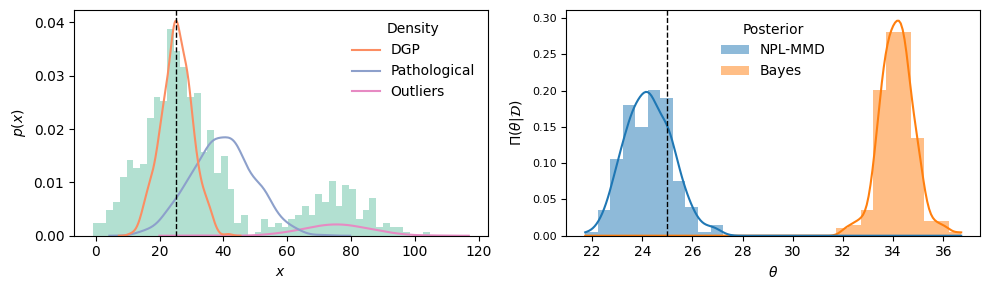

In [20]:
import seaborn as sns
from matplotlib import pyplot

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,3), sharex=False) #, sharey=True) 
pal = sns.color_palette("Set2")
pal2 = sns.color_palette("viridis")
plt.rcParams['patch.linewidth'] = 0

data_true = sample_dgp("contaminated_normal", 1000, contaminations[0])
data_observed, outl = contaminated_normal(600, contaminations[1])
data_pathological = norm.rvs(
            loc=40,
            scale=DGP_STD_TRUNCATED_NORMAL,
            size=1000,
            random_state=generator,
        )

data_df = pd.DataFrame({
    'Value': np.concatenate([data_true, data_pathological, outl]),
    'Density': ['DGP'] * len(data_true) + ['Pathological'] * len(data_pathological) + ['Outliers']*len(outl)  # Create a label for each dataset
})

data_df_obs = pd.DataFrame({
    'Value': data_observed,
    'Dataset': ['Observed data']*len(data_observed)  # Create a label for each dataset
})

posterior_df = pd.DataFrame({
    'Value': np.concatenate([theta_sample_mmd.squeeze(), theta_sample_kl]),
    'Posterior': ['NPL-MMD'] * len(theta_sample_mmd) + ['Bayes'] * len(theta_sample_kl)  # Create a label for each dataset
})

means = [25, 25, 40]
titles = ["DGP and Pathological model", "Contaminated observed data", "Pathological case"]


ax = axes[0]
sns.histplot(data=data_df_obs, x='Value', hue='Dataset', ax=ax, bins=50, palette=pal, stat='density', kde=False)  #kde=True
# sns.rugplot(outl, color=pal2[1], ax=ax, height=0.03)
# ax.axvline(x=75, color='gray', linestyle='--', lw=1, label='Outliers mean')
# ax.axvline(x=means[0], color='black', linestyle='--', lw=1, label='True mean')
# ax.set_title(titles[1])
sns.kdeplot(data=data_df, x='Value', hue='Density', ax=ax, palette=pal[1:])
l = ax.axvline(x=means[0], color='black', linestyle='--', lw=1, label='True mean')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$p(x)$')
# ax.set_title('Observed data')
# leg1 = ax.legend(pal[0], loc="upper left", title="Legend")
# ax.add_artist(leg1)


# sns.histplot(datasets[2], ax=ax, bins=30, color=pal[2], edgecolor=pal[i], kde=True, label="Pathological", legend="False")
# ax.axvline(x=means[2], color=pal[1], linestyle='--', lw=1, label='Pathological mean')
# ax.axvline(x=means[0], color=pal[0], linestyle='--', lw=1, label='True mean')
# ax.set_title(titles[0])
# ax.legend()

ax = axes[1]
sns.histplot(data=posterior_df, x='Value', hue='Posterior', ax=ax, fill=True, color=pal2, stat='density', legend=True, kde=True, bins=30)
# children = ax.get_children()
# ax.axvline(x=means[0], color='black', linestyle='--', lw=1)

# ax = axes[1][1]
# sns.histplot(theta_sample_kl, ax=ax, fill=True, color=pal2[2], stat='density', kde=True, bins=30)
l = ax.axvline(x=means[0], color='black', linestyle='--', lw=1, label='True mean')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\Pi(\theta | \mathcal{D})$')
ax.tick_params(labelbottom=True)
# ax.set_title('NPL-MMD and Bayes posterior samples')
# ax.legend([children[0], children[1], l], ['NPL-MMD', 'Bayes', 'True mean'] )
# ax.legend()

plt.tick_params(axis='y', labelsize=8) 
plt.tight_layout()
plt.show()

In [43]:
theta_sample_mmd.shape

(100, 1)

In [81]:
pip install seaborn

/usr/lib64/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
